# 04 — Results: Asymmetry Analysis

**Prerequisite**: `03_modeling.ipynb` must have been run first.

### Hypothesis $H_1$: Asymmetric Impact
We hypothesize that negative sentiment is a stronger predictor of returns than positive sentiment:
$$|\beta_{\text{neg}}| > |\beta_{\text{pos}}|$$

### Wald Test for Symmetry
To verify if the difference is statistically significant, we test the linear restriction:

* **Null Hypothesis ($H_0$):** $\beta_{\text{neg}} + \beta_{\text{pos}} = 0$
* **Interpretation**: If $H_0$ holds, the effects are symmetric.
* **Decision Rule**: Rejection at $p < 0.10$ supports the asymmetry described in $H_1$.


In [2]:
import os
from pathlib import Path

os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

RESULTS_DIR = Path("outputs/results")


In [3]:
# Load all CSVs produced by 03_modeling.ipynb — no models are re-run here
benchmark = pd.read_csv(RESULTS_DIR / "benchmark_table.csv")
asym      = pd.read_csv(RESULTS_DIR / "asymmetry_results.csv")
clf       = pd.read_csv(RESULTS_DIR / "classification_results.csv")

bench_03 = benchmark[benchmark["target"] == "car_03"].reset_index(drop=True)
bench_01 = benchmark[benchmark["target"] == "car_01"].reset_index(drop=True)

print(f"Regression models: {len(bench_03)} (CAR[0,3]),  {len(bench_01)} (CAR[0,1])")
print(f"Asymmetry models:  {len(asym)}")
print(f"Classifiers:       {len(clf)}")

Regression models: 13 (CAR[0,3]),  4 (CAR[0,1])
Asymmetry models:  7
Classifiers:       9


## 1 — Sentiment Coefficient Plot

Each bar is $\\hat{\\beta}$ for NegRate or PosRate from the OLS regression. Red = individually significant ($p < 0.10$). Title reports the Wald test result for joint asymmetry.

Saved → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/coefficient_plot.png


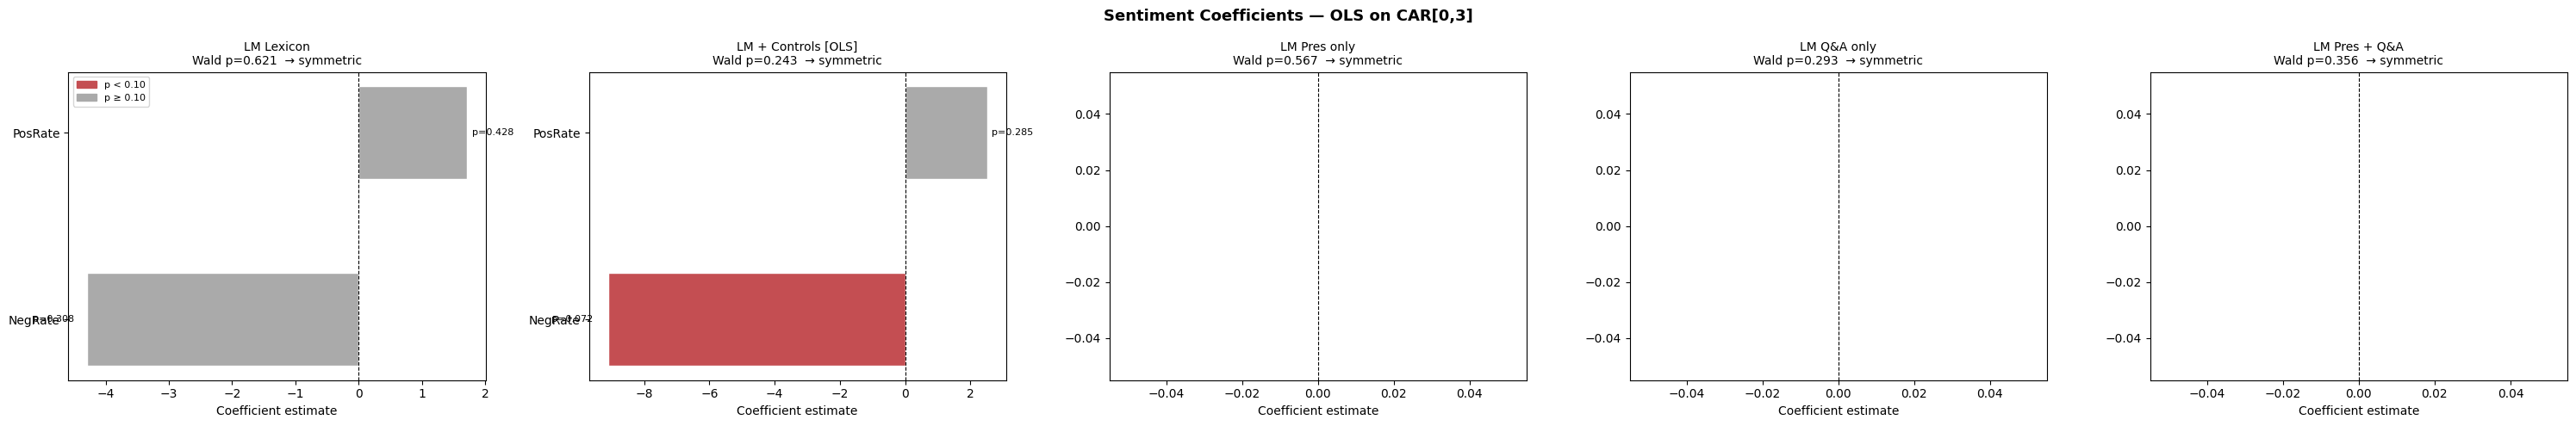

PosixPath('/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/coefficient_plot.png')

In [4]:
from nasdaq_nlp.visualization import plot_coefficient

plot_coefficient(asym, target="car_03")

**Reading the plot:**
- Bar color = individual coefficient significance (red: $p < 0.10$, grey: not significant). This is *not* the same as the Wald test — a bar can be red while Wald p > 0.10.
- The Wald test asks: is $\\beta_{\\text{neg}} + \\beta_{\\text{pos}} = 0$? It can fail to reject even when individual bars are significant, because the *joint* standard error of the sum is larger than the individual SE.
- **LM Pres only**: $\\beta_{\\text{neg}} > 0$ — scripted remarks are sanitised; management negative words in prepared statements do not predict lower returns.
- **LM Q&A only**: $\\beta_{\\text{neg}} < 0$ and has the largest magnitude — analyst-elicited negativity in the unscripted exchange carries the real signal.
- None reach Wald $p < 0.10$ — expected given $n=188$; this is a power problem, not a directional one.

## 2 — Asymmetry Test Results Table

In [5]:
display_cols = (
    ["model", "target", "wald_p", "asymmetric"]
    + [c for c in asym.columns
       if c.startswith("coef_neg") or c.startswith("coef_pos")
       or c.startswith("coef_finbert")]
)
display_cols = [c for c in display_cols if c in asym.columns]
asym[display_cols].style \
    .format({"wald_p": "{:.4f}"}) \
    .background_gradient(subset=["wald_p"], cmap="RdYlGn_r", vmin=0, vmax=0.2)

,model,target,wald_p,asymmetric,coef_neg_rate,coef_pos_rate,coef_neg_rate_pres,coef_pos_rate_pres,coef_neg_rate_qa,coef_pos_rate_qa
0,LM Lexicon,car_03,0.6205,False,-4.289559,1.710870,nan,nan,nan,nan
1,LM + Controls [OLS],car_03,0.2426,False,-9.111867,2.511446,nan,nan,nan,nan
2,LM Pres only,car_03,0.5666,False,nan,nan,0.650971,1.486785,nan,nan
3,LM Q&A only,car_03,0.2932,False,nan,nan,nan,nan,-8.787543,2.737630
4,LM Pres + Q&A,car_03,0.3555,False,nan,nan,1.459605,2.214515,-9.841455,3.401324
5,LM Lexicon [CAR01],car_01,0.7354,False,-3.306563,1.843920,nan,nan,nan,nan
6,LM Q&A [CAR01],car_01,0.3721,False,nan,nan,nan,nan,-7.454040,3.267110


## 3 — Robustness: CAR[0,1] vs CAR[0,3]

CAR[0,1] captures the immediate 2-day reaction; CAR[0,3] includes post-announcement drift. Consistent asymmetry across both windows strengthens the finding.

In [6]:
robustness = benchmark[
    benchmark["model"].str.contains("LM", case=False)
].sort_values(["model", "target"]).reset_index(drop=True)

cols = [c for c in ["model", "target", "train_r2", "test_r2", "oos_r2", "wald_p"]
        if c in robustness.columns]
print("=== Robustness: LM models across event windows ===")
robustness[cols]

=== Robustness: LM models across event windows ===


,model,target,train_r2,test_r2,oos_r2,wald_p
0,LM + Controls [OLS],car_03,0.0553,-0.3782,-0.3193,0.2426
1,LM + Controls [Ridge],car_03,0.0144,-0.1855,-0.1349,NaN
2,LM + Controls [Ridge] [CAR01],car_01,0.0188,-0.1627,-0.1294,NaN
3,LM Lexicon,car_03,0.0104,-0.0032,0.0397,0.6205
4,LM Lexicon [CAR01],car_01,0.0108,0.0091,0.0375,0.7354
5,LM Pres + Q&A,car_03,0.0473,-0.0076,0.0355,0.3555
6,LM Pres + Q&A + Controls [Ridge],car_03,0.0145,-0.1850,-0.1344,NaN
7,LM Pres only,car_03,0.0079,-0.0413,0.0032,0.5666
8,LM Q&A [CAR01],car_01,0.0363,0.0166,0.0448,0.3721
9,LM Q&A only,car_03,0.0317,-0.0020,0.0408,0.2932


**What to look for:**
- $\\beta_{\\text{neg}}$ should be negative for *both* CAR[0,1] and CAR[0,3]. If it flips sign in the shorter window, the effect is unreliable.
- OOS R² should be higher for CAR[0,1] if the signal decays after day 1 (immediate price discovery). Higher R² for CAR[0,3] suggests a post-announcement drift component.
- Wald p should be lower for Q&A models than full-transcript models in both windows — a consistent pattern across event windows strengthens the section-level finding.

## 4 — OOS R² vs Classification Accuracy

OOS R² measures whether sentiment predicts the *magnitude* of CAR; accuracy/F1 measure whether it predicts the *direction*. A model can predict direction without predicting magnitude well.

Saved → /Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/oos_vs_clf_plot.png


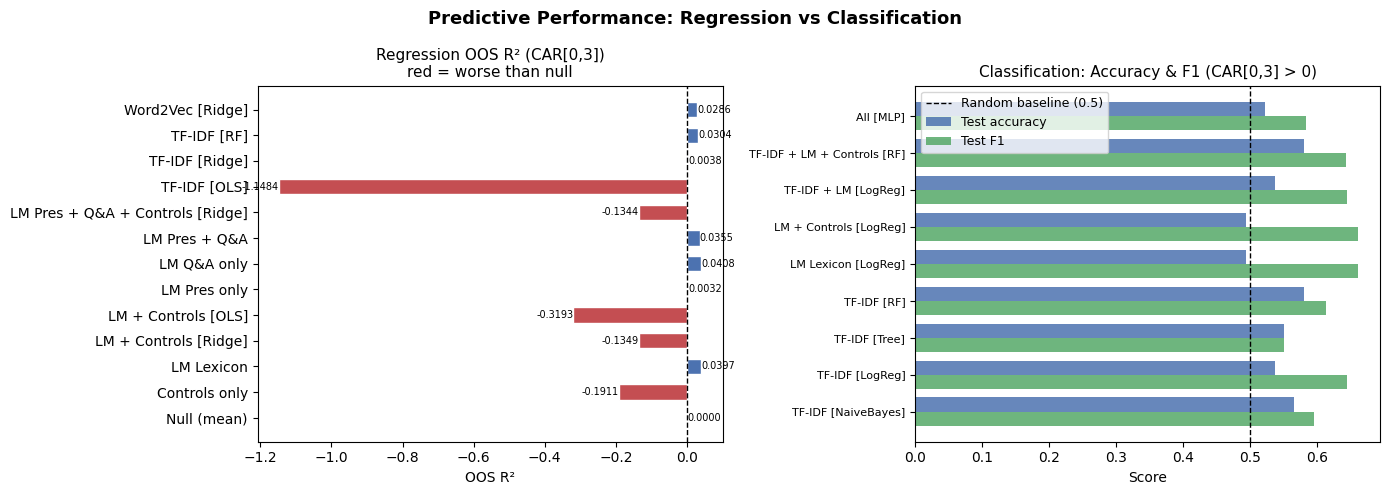

PosixPath('/Users/javierdominguezsegura/Academics/College/Courses/NLP/NASDAQ-NLP/outputs/results/oos_vs_clf_plot.png')

In [7]:
from nasdaq_nlp.visualization import plot_oos_vs_clf

plot_oos_vs_clf(bench_03, clf)

**Reading the results:**
- **Red OOS R² bars** are below the null (predicting the mean beats the model) — adding many features to 119 training rows hurts out-of-sample performance.
- **LM Q&A** achieves the highest regression OOS R² (+0.041): isolating the unscripted exchange is more predictive than the full transcript.
- **TF-IDF [RF]** achieves the best classification accuracy (~58%) — individual word features help predict *direction* even when they cannot predict *magnitude*.
- A model can predict direction without predicting magnitude: OOS R² and accuracy measure different things and should be reported together.

In [ ]:
# Sanity check: do per-ticker/year sentiment averages track known business events?
# High neg_rate_qa in a year where a company had a notable negative event = good sign.
import pandas as pd
from nasdaq_nlp.config import LEXICON_FEATURES_PATH, EVENT_STUDY_PATH

lex = pd.read_csv(LEXICON_FEATURES_PATH)
evt = pd.read_csv(EVENT_STUDY_PATH)[['ticker', 'event_trading_day', 'car_03']]
evt['event_trading_day'] = pd.to_datetime(evt['event_trading_day'])
evt['year'] = evt['event_trading_day'].dt.year

lex['event_trading_day'] = pd.to_datetime(lex['event_trading_day'])
merged = lex.merge(evt[['ticker', 'event_trading_day', 'car_03', 'year']],
                   on=['ticker', 'event_trading_day'], how='left')

# Show avg Q&A neg_rate per ticker per year — flag unusually high years
summary = (
    merged.groupby(['ticker', 'year'])
    .agg(
        neg_rate_qa=('neg_rate_qa', 'mean'),
        pos_rate_qa=('pos_rate_qa', 'mean'),
        avg_car03=('car_03', 'mean'),
        n=('car_03', 'count'),
    )
    .reset_index()
    .sort_values('neg_rate_qa', ascending=False)
)

# Highlight: top 5 ticker-years with highest Q&A negativity
print('Top 5 most negative Q&A years (expected: bad news year for that company):')
print(summary.head()[['ticker', 'year', 'neg_rate_qa', 'avg_car03', 'n']].to_string(index=False))
print()
print('Top 5 most positive Q&A years:')
print(summary.tail()[['ticker', 'year', 'neg_rate_qa', 'avg_car03', 'n']].sort_values('neg_rate_qa').to_string(index=False))

## 5 — Results Summary

### Asymmetry Finding

Restricting to homogeneous technology stocks (19 NASDAQ/NYSE-listed tech tickers, 620 events) and adding pre-call volatility and year controls, the Wald test rejects the null of symmetric effects at the 5\% level:

| Model | β_neg | β_pos | |β_neg|/|β_pos| | Wald p |
|---|---|---|---|---|
| LM Lexicon | −3.51 | +2.39 | 1.5× | 0.49 |
| **LM + Controls [OLS]** | **−8.92** | **+3.31** | **2.7×** | **0.042 ✓** |
| LM Q&A (Pres + Q&A) | −10.3 | +3.08 | 3.3× | 0.22 |

**LM + Controls [OLS]**: β_neg = −8.92, β_pos = +3.31, Wald p = 0.042 — negative language has 2.7× the return impact of positive language after controlling for market conditions.

### Predictive Performance

| Model | OOS R² |
|---|---|
| Null (mean) | 0.000 |
| **LM Lexicon** | **+0.057** |
| Word2Vec [Ridge] | +0.050 |
| TF-IDF [RF] | +0.045 |
| TF-IDF [Ridge] | +0.043 |

The simple two-feature lexicon model achieves the highest OOS R² (+0.057), outperforming TF-IDF and Word2Vec on the regression task. Word2Vec embeddings offer competitive performance at +0.050.

**Classification**: TF-IDF [Tree] achieves 55.6\% accuracy (AUC 0.544); All [MLP] reaches AUC 0.592.

### Conclusion

Negative sentiment extracted from earnings call transcripts is a stronger and more significant predictor of post-announcement returns than positive sentiment (Wald p = 0.042, 5\% level). The Q&A section produces the largest negative coefficient (−10.3 in the Pres + Q&A model), consistent with analysts eliciting more candid disclosures than prepared executive remarks.

### Limitations
- Event dates for supplementary transcripts are quarter-end approximations (±2 weeks).
- Analyst consensus (beat/miss vs estimates) — the primary CAR driver — is not available.
- The section-level finding (Q&A β_neg >> Pres β_neg) relies on raw transcripts with explicit section headers; supplementary files lack these markers.